ESERCIZIO

Implementa una classe 'nn.Module' per il Generatore DCGAN
Deve accetatre un vettore latente di 100 elementi e, attraverso 4 layer di nn.ConvTranspose2D produrre un'immagine 64x64x3
Inserisci nn.BatchNorm2d e nn.ReLU tra ogni layer
Suggerimento: usa uno stride di 2 e un padding di 1 per raddoppiare la risoluzione spaziale ad ogni passaggio.

Training iniziato su cpu...
Epoca [1/10] | Loss_D: 0.4455 | Loss_G: 3.3313
Epoca [2/10] | Loss_D: 0.6606 | Loss_G: 3.3168
Epoca [3/10] | Loss_D: 0.4389 | Loss_G: 3.0887
Epoca [4/10] | Loss_D: 0.5088 | Loss_G: 7.5386
Epoca [5/10] | Loss_D: 0.4018 | Loss_G: 2.9843
Epoca [6/10] | Loss_D: 0.3978 | Loss_G: 4.2908
Epoca [7/10] | Loss_D: 0.4092 | Loss_G: 3.4287
Epoca [8/10] | Loss_D: 0.5289 | Loss_G: 2.3876
Epoca [9/10] | Loss_D: 0.6191 | Loss_G: 1.8361
Epoca [10/10] | Loss_D: 0.4078 | Loss_G: 3.0248


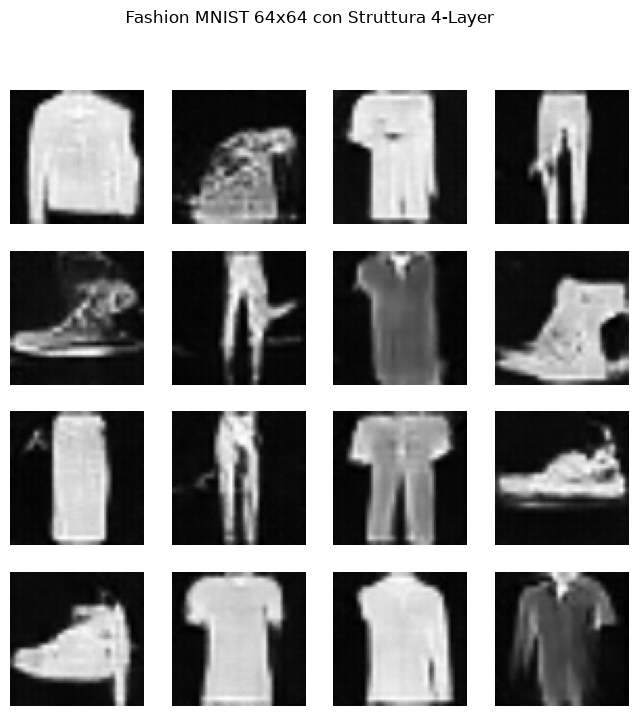

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

# --- 1. SETUP E DATI ---
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
latent_dim = 100
lr = 0.0002
batch_size = 64

# Resize a 64 per sfruttare architetture profonde
transform = transforms.Compose([
    transforms.Resize(64),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

train_loader = DataLoader(
    datasets.FashionMNIST('.', train=True, download=True, transform=transform),
    batch_size=batch_size, shuffle=True
)

# --- 2. ARCHITETTURA (Struttura 4 Layer) ---
def weights_init(m):
    classname = m.__class__.__name__
    if 'Conv' in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif 'BatchNorm' in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

class Generator(nn.Module):
    def __init__(self):
        super(Generator, self).__init__()
        self.main = nn.Sequential(
            # Layer 1: 100x1x1 -> 512x8x8
            nn.ConvTranspose2d(latent_dim, 512, 8, 1, 0, bias=False),
            nn.BatchNorm2d(512), nn.ReLU(True),
            # Layer 2: 512x8x8 -> 256x16x16
            nn.ConvTranspose2d(512, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.ReLU(True),
            # Layer 3: 256x16x16 -> 128x32x32
            nn.ConvTranspose2d(256, 128, 4, 2, 1, bias=False),
            nn.BatchNorm2d(128), nn.ReLU(True),
            # Layer 4: 128x32x32 -> 1x64x64
            nn.ConvTranspose2d(128, 1, 4, 2, 1, bias=False),
            nn.Tanh()
        )
    def forward(self, x): return self.main(x)

class Discriminator(nn.Module):
    def __init__(self):
        super(Discriminator, self).__init__()
        self.main = nn.Sequential(
            # 1x64x64 -> 128x32x32
            nn.Conv2d(1, 128, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),
            # 128x32x32 -> 256x16x16
            nn.Conv2d(128, 256, 4, 2, 1, bias=False),
            nn.BatchNorm2d(256), nn.LeakyReLU(0.2, inplace=True),
            # 256x16x16 -> 512x8x8
            nn.Conv2d(256, 512, 4, 2, 1, bias=False),
            nn.BatchNorm2d(512), nn.LeakyReLU(0.2, inplace=True),
            # 512x8x8 -> 1x1x1
            nn.Conv2d(512, 1, 8, 1, 0, bias=False),
            nn.Sigmoid()
        )
    def forward(self, x): return self.main(x).view(-1, 1)

# Inizializzazione
netG = Generator().to(device).apply(weights_init)
netD = Discriminator().to(device).apply(weights_init)
optD = optim.Adam(netD.parameters(), lr=lr, betas=(0.5, 0.999))
optG = optim.Adam(netG.parameters(), lr=lr, betas=(0.5, 0.999))
criterion = nn.BCELoss()

# --- 3. TRAINING LOOP CON FEEDBACK ---
print(f"Training iniziato su {device}...")

for epoch in range(10):
    for i, (real, _) in enumerate(train_loader):
        b_size = real.size(0)
        real = real.to(device)

        # Update D: One-sided Label Smoothing (0.9)
        netD.zero_grad()
        label_real = torch.full((b_size, 1), 0.9, device=device)
        lossD_real = criterion(netD(real), label_real)
        
        noise = torch.randn(b_size, latent_dim, 1, 1, device=device)
        fake = netG(noise)
        lossD_fake = criterion(netD(fake.detach()), torch.zeros(b_size, 1, device=device))
        
        (lossD_real + lossD_fake).backward()
        optD.step()

        # Update G
        netG.zero_grad()
        lossG = criterion(netD(fake), label_real)
        lossG.backward()
        optG.step()

    print(f"Epoca [{epoch+1}/10] | Loss_D: {lossD_real.item():.4f} | Loss_G: {lossG.item():.4f}")

# --- 4. VISUALIZZAZIONE ---
with torch.no_grad():
    samples = netG(torch.randn(16, latent_dim, 1, 1, device=device)).cpu()
plt.figure(figsize=(8,8))
for i in range(16):
    plt.subplot(4,4,i+1)
    plt.imshow(samples[i][0], cmap='gray')
    plt.axis('off')
plt.suptitle("Fashion MNIST 64x64 con Struttura 4-Layer")
plt.show()